In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
path = r"C:\Users\Noble Adike\Desktop\Coding\KPMG\kpmg-1a\data\harvard\Year 1 (Jun 2022 - May 2023)\Facade_temp_hourly\48190939_Facade_temp_hourly.csv"
df = pd.read_csv(path)

In [3]:
df.head()

,Timestamp,East_facade_high_temp,East_facade_low_temp,North_facade_high_temp,North_facade_low_temp,South_facade_high_temp,South_facade_low_temp,South_facade_mid_temp,West_facade_high_left_temp,West_facade_high_right_temp
0,2022-06-01 00:00:00-04:00,56.273857,57.417967,57.708367,57.019656,59.447463,58.172017,58.348897,58.093806,56.613096
1,2022-06-01 01:00:00-04:00,56.489347,57.362527,58.496406,57.137136,59.507193,58.028137,58.088857,57.882607,56.563268
2,2022-06-01 02:00:00-04:00,56.604847,57.517957,57.346687,57.145716,58.557126,58.187197,58.064767,58.190497,56.666227
3,2022-06-01 03:00:00-04:00,56.675797,57.477366,57.177728,57.124926,57.898116,58.305997,57.823867,57.841687,56.757308
4,2022-06-01 04:00:00-04:00,57.090608,57.851257,57.646987,57.624546,58.268047,58.503667,58.208647,58.071037,57.112386


In [4]:
df.describe()

,East_facade_high_temp,East_facade_low_temp,North_facade_high_temp,North_facade_low_temp,South_facade_high_temp,South_facade_low_temp,South_facade_mid_temp,West_facade_high_left_temp,West_facade_high_right_temp
count,4653.000000,8646.000000,8646.000000,8646.000000,8646.000000,8646.000000,8646.000000,8646.000000,8646.000000
mean,63.974623,55.921449,55.235395,54.678730,56.794003,55.819130,56.821443,56.391313,55.252007
std,15.599501,17.979177,17.472251,17.334155,18.163297,18.070781,18.924372,19.008079,17.629391
min,22.535319,1.498458,1.250684,0.676967,1.042914,2.028442,1.574709,0.457990,0.991230
25%,53.800836,41.388382,41.035776,40.584832,42.088889,41.010862,41.537790,41.137334,40.963507
50%,65.852761,54.966726,54.400446,53.811891,56.020912,54.874821,55.491426,55.056981,54.509842
75%,75.095069,69.374725,68.947004,68.312166,70.240768,69.313716,70.307596,69.825216,68.931991
max,100.215989,106.061940,100.165170,99.029971,105.857008,109.653000,112.735528,115.766911,99.815040


In [5]:
df.isna().sum().sort_values()

Timestamp                         0
East_facade_low_temp            114
North_facade_high_temp          114
North_facade_low_temp           114
South_facade_low_temp           114
South_facade_high_temp          114
South_facade_mid_temp           114
West_facade_high_left_temp      114
West_facade_high_right_temp     114
East_facade_high_temp          4107
dtype: int64

In [6]:
col = 'East_facade_high_temp'
df[col].dtype  # should be float
bad = df[col].astype(str).str.extract(r'([^0-9\.\-eE])', expand=False)
df.loc[bad.notna(), col].head(10)  #

1168   NaN
1169   NaN
1170   NaN
1171   NaN
1172   NaN
1173   NaN
1174   NaN
1175   NaN
1176   NaN
1177   NaN
Name: East_facade_high_temp, dtype: float64

In [6]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.set_index('Timestamp')

C:\Users\Noble Adike\AppData\Local\Temp\ipykernel_16160\330094659.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


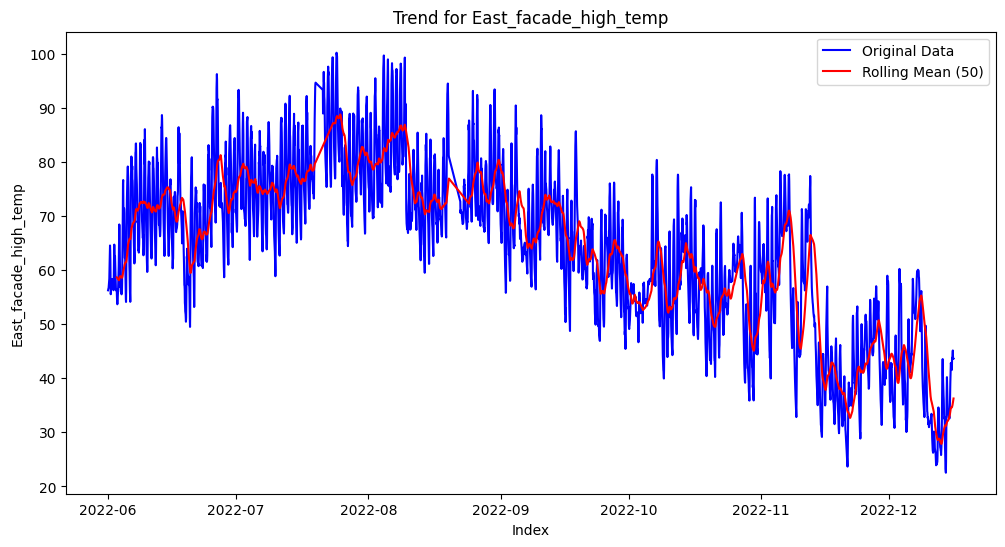

In [7]:
def check_trend(df, column):
    plt.figure(figsize=(12, 6))
    
    # Plot the original column data
    sns.lineplot(data=df, x=df.index, y=column, label='Original Data', color='blue')
    
    # Plot a rolling mean (optional, you can adjust the window size)
    rolling_mean = df[column].rolling(window=50).mean()  # 50-point moving average (can adjust)
    sns.lineplot(data=df, x=df.index, y=rolling_mean, label='Rolling Mean (50)', color='red')
    
    plt.title(f"Trend for {column}")
    plt.xlabel("Index")
    plt.ylabel(column)
    plt.legend()
    plt.show()

check_trend(df, 'East_facade_high_temp')

In [9]:
df['East_facade_high_temp'] = df['East_facade_high_temp'].fillna(method='ffill').fillna(method='bfill')

C:\Users\Noble Adike\AppData\Local\Temp\ipykernel_16160\355375597.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['East_facade_high_temp'] = df['East_facade_high_temp'].fillna(method='ffill').fillna(method='bfill')


In [11]:
df.isna().sum().sort_values()

East_facade_high_temp            0
East_facade_low_temp           114
North_facade_high_temp         114
North_facade_low_temp          114
South_facade_high_temp         114
South_facade_low_temp          114
South_facade_mid_temp          114
West_facade_high_left_temp     114
West_facade_high_right_temp    114
dtype: int64

In [12]:
df.describe()

,East_facade_high_temp,East_facade_low_temp,North_facade_high_temp,North_facade_low_temp,South_facade_high_temp,South_facade_low_temp,South_facade_mid_temp,West_facade_high_left_temp,West_facade_high_right_temp
count,8760.000000,8646.000000,8646.000000,8646.000000,8646.000000,8646.000000,8646.000000,8646.000000,8646.000000
mean,54.936490,55.921449,55.235395,54.678730,56.794003,55.819130,56.821443,56.391313,55.252007
std,15.594919,17.979177,17.472251,17.334155,18.163297,18.070781,18.924372,19.008079,17.629391
min,22.535319,1.498458,1.250684,0.676967,1.042914,2.028442,1.574709,0.457990,0.991230
25%,43.626607,41.388382,41.035776,40.584832,42.088889,41.010862,41.537790,41.137334,40.963507
50%,43.626607,54.966726,54.400446,53.811891,56.020912,54.874821,55.491426,55.056981,54.509842
75%,67.829706,69.374725,68.947004,68.312166,70.240768,69.313716,70.307596,69.825216,68.931991
max,100.215989,106.061940,100.165170,99.029971,105.857008,109.653000,112.735528,115.766911,99.815040


In [16]:
for col in df.columns:
    if df[col].isna().sum() > 0:
        print(f"{col} had {df[col].isna().sum()} missing values.")
        df[col] = df[col].fillna(method='ffill').fillna(method='bfill')